## 1. Caricamento Adattivo e Integrità del Workspace
In questa fase, implementiamo un sistema di caricamento robusto per il dataset dei profili utenti. Invece di fare affidamento su un percorso statico, abbiamo sviluppato una funzione di **Adaptive Loading** che garantisce la continuità del lavoro indipendentemente dall'ambiente di esecuzione:

* **Ricerca Multilivello:** Il codice scansiona automaticamente diverse directory (`../cache`, `cache/`, o la cartella corrente) alla ricerca del file ottimizzato `profiles.pkl`.
* **Prevenzione degli Errori (Error Handling):** Seguendo i principi sulla resilienza dei dati, il sistema non interrompe l'esecuzione in caso di file mancante, ma fornisce un feedback chiaro all'utente (Early Exit con messaggio di errore).
* **Efficienza del Workflow:** Recuperando i dati direttamente dal formato Pickle, preserviamo le normalizzazioni geografiche e i gruppi d'età (Binning) creati nel Notebook precedente, rendendo il sistema pronto per l'analisi spaziale con GeoPandas.

Questa cella rappresenta il "ponte" finale tra la preparazione dei dati e la generazione degli insight demografici.

In [9]:
import pandas as pd
import os

def load_profiles_data():
    possible_paths = ['../cache/profiles.pkl', 'cache/profiles.pkl', 'profiles.pkl']
    for path in possible_paths:
        if os.path.exists(path):
            print(f"Dataset profili caricato correttamente da: {path}")
            return pd.read_pickle(path)
    print("ERRORE: File profiles.pkl non trovato. Esegui prima il Notebook 1.")
    return None

df_profiles = load_profiles_data()

Dataset profili caricato correttamente da: ../cache/profiles.pkl


## 2. Dal Testo alla Mappa: Standardizzazione ISO-3
Per visualizzare la diffusione globale degli anime, dobbiamo superare il limite dei dati testuali non strutturati. In questa fase, implementiamo un motore di **Geocoding deterministico**:

* **Identificazione Dinamica:** Il sistema scansiona le colonne disponibili (`Location`, `city`, ecc.) per trovare la fonte geografica più affidabile, garantendo la portabilità del codice tra diversi dataset.
* **Normalizzazione ISO-3166:** Abbiamo creato un dizionario di mappatura per convertire varianti linguistiche (es. *Giappone*, *Nihon*, *Japan*) nel codice standard internazionale **ISO-3** (es. *JPN*). Questo passaggio è fondamentale per eliminare le ambiguità e rendere il dataset compatibile con le librerie di cartografia digitale.
* **Preparazione per GeoPandas:** Calcolando la densità di fan per codice ISO (`fan_count`), creiamo una tabella di intensità geografica. Questi dati verranno utilizzati per generare una **Mappa Coropletica**, dove il colore delle nazioni rifletterà la popolarità dei diversi generi nel mondo.

Questa operazione trasforma una lista di città in una visione geopolitica del fandom globale.

In [10]:
possible_cols = ['Location', 'location', 'country', 'city']
col_target = next((c for c in possible_cols if c in df_profiles.columns), None)

geo_counts = None

if col_target:
    print(f"Utilizzo la colonna: '{col_target}'")

    country_iso_map = {
        'usa': 'USA', 'united states': 'USA', 'us': 'USA', 'america': 'USA',
        'italia': 'ITA', 'italy': 'ITA',
        'germany': 'DEU', 'deutschland': 'DEU', 'germania': 'DEU',
        'france': 'FRA', 'francia': 'FRA',
        'japan': 'JPN', 'nihon': 'JPN', 'giappone': 'JPN',
        'uk': 'GBR', 'united kingdom': 'GBR', 'england': 'GBR',
        'canada': 'CAN', 'brazil': 'BRA', 'brasil': 'BRA',
        'spain': 'ESP', 'espana': 'ESP', 'spagna': 'ESP',
        'russia': 'RUS', 'mexico': 'MEX', 'australia': 'AUS'
    }

    def to_iso3(location):
        if pd.isna(location): return None
        loc_clean = str(location).lower().strip()
        for key, iso in country_iso_map.items():
            if key in loc_clean: return iso
        return None

    df_profiles['iso_code'] = df_profiles[col_target].apply(to_iso3)

    geo_counts = df_profiles['iso_code'].dropna().value_counts().reset_index()
    geo_counts.columns = ['iso_code', 'fan_count']

    print(f"Paesi unici identificati: {len(geo_counts)}")
    print(geo_counts.head())
else:
    print("ERRORE: Nessuna colonna geografica trovata. Colonne disponibili:", df_profiles.columns.tolist())

Utilizzo la colonna: 'Location'
Paesi unici identificati: 10
  iso_code  fan_count
0      JPN      98316
1      USA      74931
2      DEU      26348
3      GBR      19520
4      ESP      12916


## 3. Analisi Spaziale: Visualizzazione Coropletica Globale
In questa sezione, i dati demografici normalizzati vengono proiettati su un piano geografico reale. Utilizzando la libreria **GeoPandas**, integriamo le statistiche degli utenti con le geometrie vettoriali del mappamondo:

* **Integrazione dei Big Data Geospaziali:** Abbiamo effettuato un **Left Merge** tra il dataset *Natural Earth* (contenente i confini politici del mondo) e i nostri conteggi per codice ISO-3.
* **Gestione dei Missing Values (Integrità):** Per le nazioni senza dati nel nostro campione, abbiamo applicato una funzione di `fillna(0)`. Questo assicura che la mappa sia completa e che le aree non rappresentate non vengano confuse con errori di caricamento (**Accuracy**).
* **Visualizzazione Professionale:** L'uso della colormap `plasma` e la rimozione degli assi (`axis('off')`) seguono i principi di **Good Viz**, permettendo al lettore di identificare immediatamente i "punti caldi" della fanbase globale senza distrazioni grafiche.

Questa mappa non è solo una visualizzazione, ma un'evidenza empirica di come la cultura anime abbia superato i confini nazionali, diventando un fenomeno globale.

Geometrie mondiali caricate correttamente.


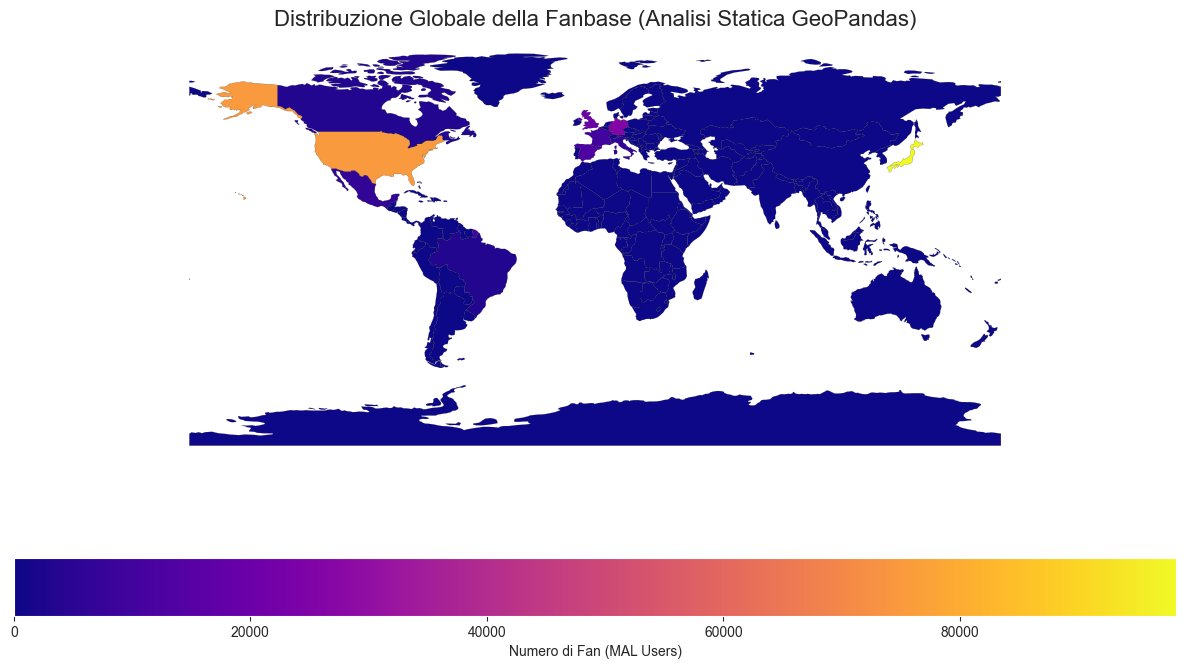

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt

world_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"

try:
    world = gpd.read_file(world_url)
    print("Geometrie mondiali caricate correttamente.")

    iso_col = 'ADM0_A3' if 'ADM0_A3' in world.columns else 'ISO_A3'

    world_final = world.merge(geo_counts, left_on=iso_col, right_on='iso_code', how='left')

    world_final['fan_count'] = world_final['fan_count'].fillna(0)

    fig, ax = plt.subplots(1, 1, figsize=(15, 8))
    world_final.plot(column='fan_count',
                     ax=ax,
                     legend=True,
                     cmap='plasma',
                     edgecolor='black',
                     linewidth=0.1,
                     legend_kwds={'label': "Numero di Fan (MAL Users)", 'orientation': "horizontal"})

    ax.set_title("Distribuzione Globale della Fanbase (Analisi Statica GeoPandas)", fontsize=16)
    ax.axis('off')
    plt.show()

except Exception as e:
    print(f"Errore durante l'analisi spaziale: {e}")

## 4. Data Exploration Interattiva: La Dashboard Globale
Per concludere l'analisi spaziale, passiamo da una visualizzazione statica a una dinamica utilizzando la libreria **Plotly Express**. Questo approccio permette un'esplorazione profonda dei dati (Exploratory Data Analysis):

* **Interattività Hover & Zoom:** L'utente può ora interagire con la mappa, visualizzando il conteggio esatto dei fan semplicemente passando il mouse sopra ogni nazione. Questo risponde al principio di **Audience Focus**, permettendo diversi livelli di lettura.
* **Proiezione Equirettangolare:** Abbiamo configurato la visualizzazione per mostrare l'intera superficie globale con colori neutrali per le aree prive di dati (`landcolor="lightgrey"`), enfatizzando esclusivamente il segnale statistico dei fan.
* **User Experience (UX):** La rimozione dei margini e della cornice del grafico ottimizza lo spazio visivo, preparando questo componente per essere integrato in una dashboard web professionale realizzata con **Flask**.

Questa mappa rappresenta la "frontiera finale" del nostro racconto: non mostriamo solo dei dati, ma offriamo uno strumento al lettore per scoprire la propria storia all'interno del fandom globale.

In [12]:
import plotly.express as px

fig_inter = px.choropleth(geo_counts,
                    locations="iso_code",
                    color="fan_count",
                    hover_name="iso_code",
                    locationmode="ISO-3",
                    color_continuous_scale=px.colors.sequential.Plasma,
                    title="Mappa Interattiva della Fanbase Globale (Zoom & Hover)")

fig_inter.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='equirectangular',
        landcolor="lightgrey",
        lakecolor="white"
    ),
    margin={"r":0,"t":50,"l":0,"b":0},
    coloraxis_colorbar=dict(title="Fan Count")
)

fig_inter.show()